In [16]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.image as mpimgfrom 
from urllib.request import urlopen
import seaborn as sns
from PIL import Image as PILImage

import io
from collections import defaultdict

import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score


from wordcloud import WordCloud

from scipy import stats
from scipy.stats import normaltest, skew, kurtosis
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import LeaveOneOut

# Объяснение датасета

Пропуски есть только в dataframe'е с книгами в признаках: isbn, isbn13, original_publication_year, original_title, language_code

Главная неочевидная особенность - у книг может быть несколько изданий. Несколько названий(локализация и оригинал).
И несколько id - сервиса и стандартизованные библиографичные. В датафрейме с книгами уже есть агрегированные данные по оценкам, которые можно было самостоятельно получить по датафрейму с оценками.

1) Датафрейм с книгами - разберем подробнее ниже
2) Датафрейм с оценками - id издания книги, пользователь, оценка
3) Датафрейм с тегами книг - id издания книги, тег, количество(сколько раз юзеры протегировали)
4) Датафрейм с тегами - id, имя
5) Датафрейм с прочитанными книгами - пользователь, id издания книги

Пропуски в данных есть только в книгах. Подробнее о его фичах(получено с помощью LLM):

### **`book_id`** 
- **Тип**: int64
- **Описание**: Внутренний уникальный идентификатор записи в датасете
- **Пример**: 1, 2, 3, ...

### **`goodreads_book_id`**
- **Тип**: int64  
- **Описание**: Уникальный идентификатор книги в системе GoodReads
- **Важность**: Ключ для соединения с ratings_df
- **Пример**: 2767052, 3, 41865

### **`best_book_id`**
- **Тип**: int64
- **Описание**: Идентификатор "лучшего" издания книги (может отличаться от book_id если есть разные издания)
- **Пример**: 2767052, 3, 41865

### **`work_id`**
- **Тип**: int64
- **Описание**: Идентификатор литературного произведения (work), которое может иметь несколько изданий
- **Пример**: 2792775, 4640799

## 📖 Библиографическая информация

### **`books_count`**
- **Тип**: int64
- **Описание**: Количество различных изданий этой книги в системе
- **Интерпретация**: Высокое значение = популярное произведение с множеством изданий
- **Пример**: 50, 120, 5

### **`isbn`**
- **Тип**: object (строка)
- **Пропуски**: 700 (7%)
- **Описание**: International Standard Book Number (10-значный)
- **Пример**: "439554934", "743477111"

### **`isbn13`**
- **Тип**: float64
- **Пропуски**: 585 (5.85%)
- **Описание**: 13-значный ISBN (современный стандарт)
- **Пример**: 9780439554930.0, 9780743477116.0

### **`authors`**
- **Тип**: object (строка)
- **Описание**: Автор(ы) книги. Если несколько авторов - разделены запятыми
- **Пример**: "J.K. Rowling", "Stephen King, Peter Straub"

### **`original_publication_year`**
- **Тип**: float64
- **Пропуски**: 21 (0.21%)
- **Описание**: Год первого издания книги
- **Пример**: 1997.0, 2003.0, 1813.0

### **`original_title`**
- **Тип**: object (строка)
- **Пропуски**: 585 (5.85%)
- **Описание**: Оригинальное название на языке публикации
- **Пример**: "Harry Potter and the Philosopher's Stone"

### **`title`**
- **Тип**: object (строка)
- **Описание**: Название книги (может быть локализованным)
- **Пример**: "Harry Potter and the Sorcerer's Stone" (американская версия)

### **`language_code`**
- **Тип**: object (строка)
- **Пропуски**: 1084 (10.84%)
- **Описание**: Код языка книги
- **Пример**: "eng", "spa", "fre", "rus"

## ⭐ Рейтинги и отзывы

### **`average_rating`**
- **Тип**: float64
- **Описание**: Средний рейтинг книги по шкале 1-5
- **Важность**: Ключевой показатель качества
- **Пример**: 4.57, 3.82, 2.15

### **`ratings_count`**
- **Тип**: int64
- **Описание**: Общее количество оценок этой книги
- **Важность**: Показатель популярности
- **Пример**: 4780653, 153558

### **`work_ratings_count`**
- **Тип**: int64
- **Описание**: Общее количество оценок для всего произведения (включая все издания)
- **Пример**: 4942365, 160173

### **`work_text_reviews_count`**
- **Тип**: int64
- **Описание**: Количество текстовых отзывов на произведение
- **Пример**: 107308, 3387

## 📊 Детальное распределение оценок

### **`ratings_1`** - **`ratings_5`**
- **Тип**: int64
- **Описание**: Количество оценок каждой звезды (от 1 до 5)
- **Важность**: Позволяет анализировать распределение мнений
- **Пример**:
  - `ratings_1`: 60437 (однозвездочные оценки)
  - `ratings_2`: 127554 (двухзвездочные)
  - `ratings_3`: 390778 (трехзвездочные) 
  - `ratings_4`: 793475 (четырехзвездочные)
  - `ratings_5`: 630656 (пятизвездочные)

## 🖼️ Медиа-контент

### **`image_url`**
- **Тип**: object (строка)
- **Описание**: URL обложки книги в высоком разрешении
- **Пример**: "https://images.gr-assets.com/books/1327942885l/2767052.jpg"

### **`small_image_url`**
- **Тип**: object (строка)
- **Описание**: URL уменьшенной версии обложки
- **Пример**: "https://images.gr-assets.com/books/1327942885s/2767052.jpg"

# Загрузка и знакомство с данными

In [21]:
books_df = pd.read_csv('../data/goodbooks-10k/books.csv')
ratings_df = pd.read_csv('../data/goodbooks-10k/ratings.csv')
book_tags_df = pd.read_csv('../data/goodbooks-10k/book_tags.csv')
tags_df = pd.read_csv('../data/goodbooks-10k/tags.csv')
to_read_df = pd.read_csv('../data/goodbooks-10k/to_read.csv')

In [22]:
books_df

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7130616,7130616,7392860,19,441019455,9.780441e+12,Ilona Andrews,2010.0,Bayou Moon,...,17204,18856,1180,105,575,3538,7860,6778,https://images.gr-assets.com/books/1307445460m...,https://images.gr-assets.com/books/1307445460s...
9996,9997,208324,208324,1084709,19,067973371X,9.780680e+12,Robert A. Caro,1990.0,Means of Ascent,...,12582,12952,395,303,551,1737,3389,6972,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
9997,9998,77431,77431,2393986,60,039330762X,9.780393e+12,Patrick O'Brian,1977.0,The Mauritius Command,...,9421,10733,374,11,111,1191,4240,5180,https://images.gr-assets.com/books/1455373531m...,https://images.gr-assets.com/books/1455373531s...
9998,9999,8565083,8565083,13433613,7,61711527,9.780062e+12,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,...,11279,11994,1988,275,1002,3765,4577,2375,https://images.gr-assets.com/books/1279214118m...,https://images.gr-assets.com/books/1279214118s...


In [23]:
len(books_df[books_df['book_id'] != books_df['best_book_id']])

10000

**На практике в нашем датасете каждая книга представлена только в одном издании. Это сильно упрощает работу.**

In [25]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

In [26]:
ratings_df

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3
...,...,...,...
5976474,49925,510,5
5976475,49925,528,4
5976476,49925,722,4
5976477,49925,949,5


In [27]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB


In [28]:
book_tags_df

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716
...,...,...,...
999907,33288638,21303,7
999908,33288638,17271,7
999909,33288638,1126,7
999910,33288638,11478,7


In [29]:
book_tags_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999912 entries, 0 to 999911
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   goodreads_book_id  999912 non-null  int64
 1   tag_id             999912 non-null  int64
 2   count              999912 non-null  int64
dtypes: int64(3)
memory usage: 22.9 MB


In [30]:
tags_df

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-
...,...,...
34247,34247,Ｃhildrens
34248,34248,Ｆａｖｏｒｉｔｅｓ
34249,34249,Ｍａｎｇａ
34250,34250,ＳＥＲＩＥＳ


In [31]:
tags_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34252 entries, 0 to 34251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tag_id    34252 non-null  int64 
 1   tag_name  34252 non-null  object
dtypes: int64(1), object(1)
memory usage: 535.3+ KB


In [32]:
to_read_df

,user_id,book_id
0,9,8
1,15,398
2,15,275
3,37,7173
4,34,380
...,...,...
912700,39374,1049
912701,10492,5180
912702,21879,4827
912703,21879,6642


In [33]:
to_read_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912705 entries, 0 to 912704
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  912705 non-null  int64
 1   book_id  912705 non-null  int64
dtypes: int64(2)
memory usage: 13.9 MB


меня смущает что везде связка идет по book_id, кроме как в book_tags_df.
надо проверить там опечатка в столбце или нет, проверим связи между book_tags_df и books_df

In [35]:
print(f"Связь book_tags_df ↔ books_df:")
common_goodreads_ids = set(book_tags_df['goodreads_book_id']).intersection(set(books_df['goodreads_book_id']))
print(f"Общих goodreads_book_id с books_df: {len(common_goodreads_ids)}")
print(f"Уникальных goodreads_book_id в book_tags_df: {book_tags_df['goodreads_book_id'].nunique()}")
print(f"Покрытие: {len(common_goodreads_ids) / book_tags_df['goodreads_book_id'].nunique() * 100:.1f}%")

Связь book_tags_df ↔ books_df:
Общих goodreads_book_id с books_df: 10000
Уникальных goodreads_book_id в book_tags_df: 10000
Покрытие: 100.0%


# Exploratory Data Analysis

## Распределение оценок

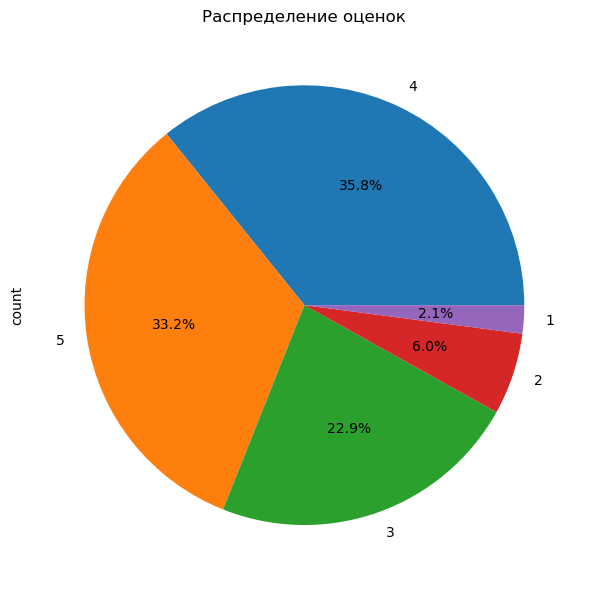

In [38]:
plt.figure(figsize=(10, 6))
ratings_df['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Распределение оценок')
plt.tight_layout()
plt.show()

Наблюдается смещение в сторону высоких оценок.

## Анализ активности пользователей

In [41]:
user_activity = ratings_df.groupby('user_id').agg(
    rating_count=('rating', 'count')
).reset_index()
user_activity = user_activity.sort_values('rating_count', ascending=False)

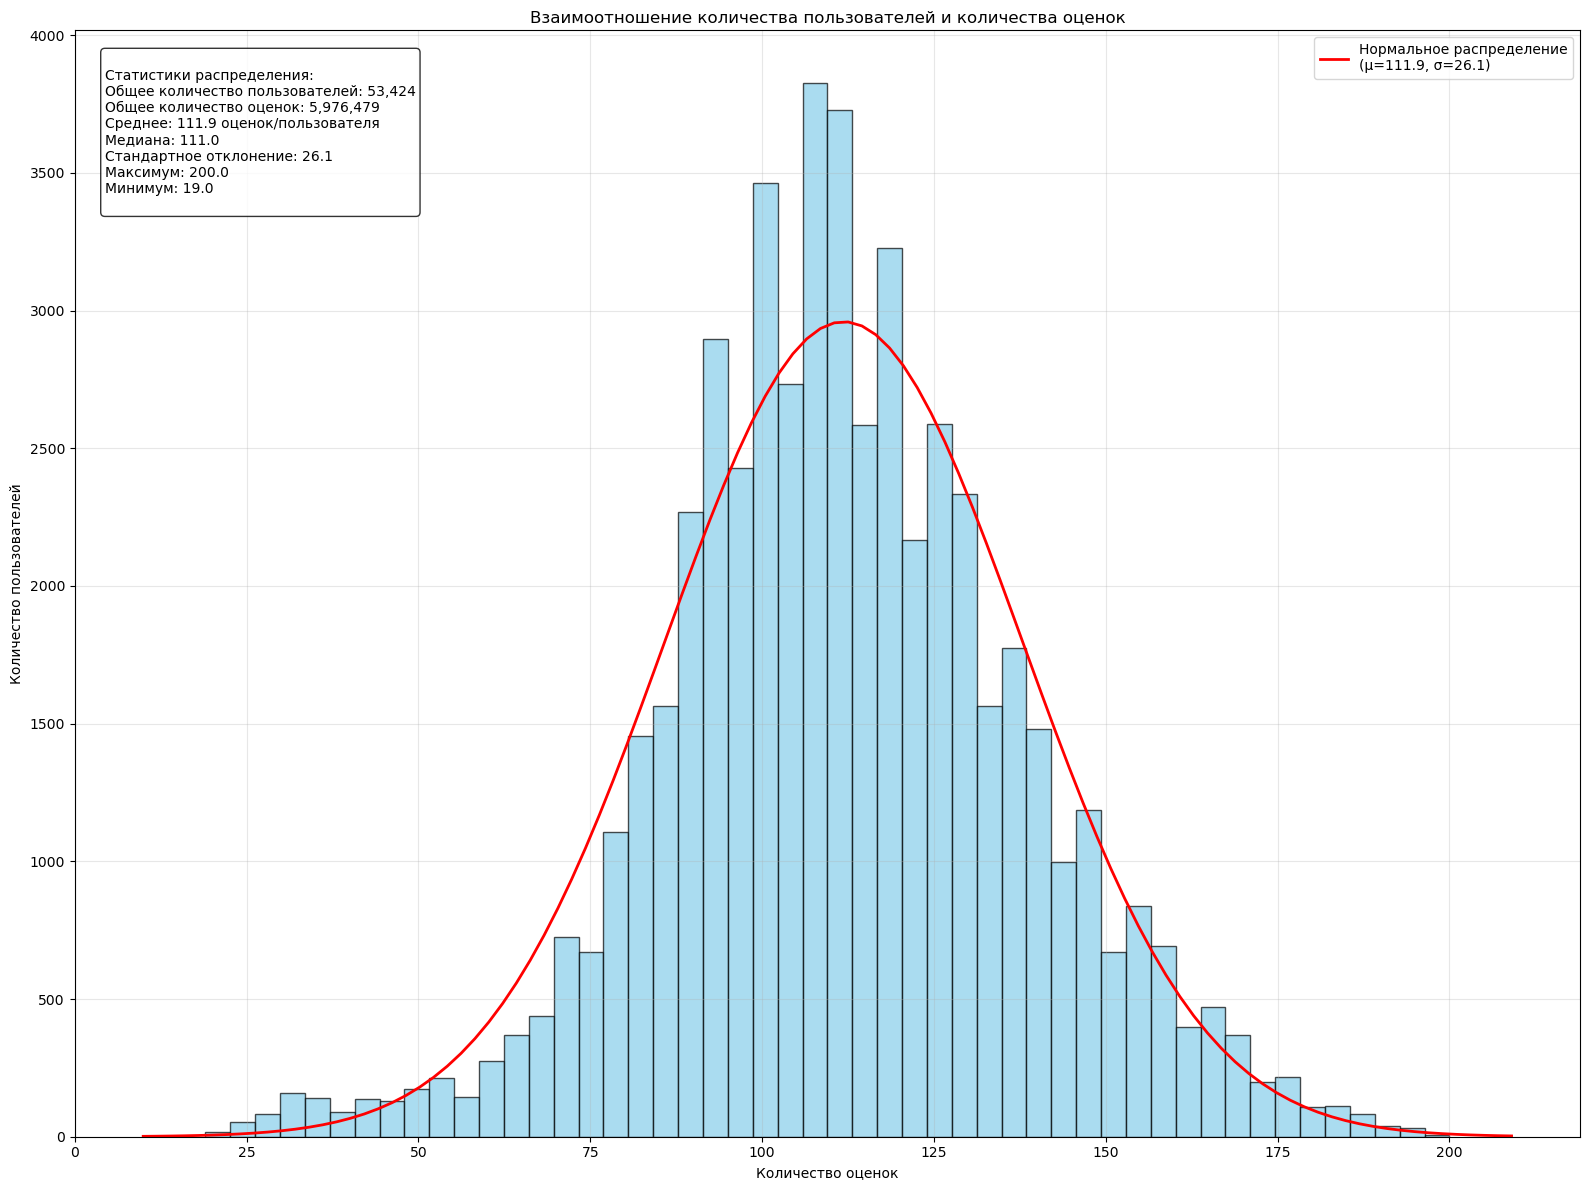

In [42]:
mu = user_activity['rating_count'].mean()
sigma = user_activity['rating_count'].std()

plt.figure(figsize=(16, 12))

n, bins, patches = plt.hist(
    user_activity['rating_count'],
    bins=50,
    alpha=0.7, 
    color='skyblue',
    edgecolor='black',
)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma) * len(user_activity) * (bins[1] - bins[0])
plt.plot(x, p, 'r-', linewidth=2, label=f'Нормальное распределение\n(μ={mu:.1f}, σ={sigma:.1f})')

plt.title('Взаимоотношение количества пользователей и количества оценок')
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.legend()

stats_text = f'''
Статистики распределения:
Общее количество пользователей: {len(user_activity):,}
Общее количество оценок: {user_activity['rating_count'].sum():,}
Среднее: {mu:.1f} оценок/пользователя
Медиана: {user_activity['rating_count'].median():.1f}
Стандартное отклонение: {sigma:.1f}
Максимум: {user_activity['rating_count'].max():.1f}
Минимум: {user_activity['rating_count'].min():.1f}
'''
plt.annotate(
    stats_text,
    xy=(0.02, 0.98),
    xycoords='axes fraction',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    verticalalignment='top',
    fontsize=10
)

plt.tight_layout()
plt.show()

In [43]:
def check_user_activity_normality(user_activity):
    data = user_activity['rating_count']

    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    if abs(skewness) < 0.5:
        skew_interpretation = "примерно симметричное"
    elif skewness > 0:
        skew_interpretation = "правосторонняя асимметрия"
    else:
        skew_interpretation = "левосторонняя асимметрия"
        
    if abs(kurtosis) < 0.5:
        kurt_interpretation = "нормальный эксцесс"
    elif kurtosis > 0:
        kurt_interpretation = "островершинное (тяжелые хвосты)"
    else:
        kurt_interpretation = "плосковершинное (легкие хвосты)"
    
    print(f"{skew_interpretation}, {kurt_interpretation}")
    print()
    
    # Статистические тесты на нормальность
    alpha = 0.05
    # Тест Д'Агостино (подходит для больших выборок)
    stat_da, p_da = normaltest(data)
    print("📈 Тест Д'Агостино на нормальность:")
    print(f"   Вывод: {'Распределение нормальное' if p_da > alpha else 'Распределение НЕ нормальное'}")
    print()
    
    # Анализ правила 68-95-99.7
    within_1std = ((data >= data.mean() - data.std()) & (data <= data.mean() + data.std())).mean() * 100
    within_2std = ((data >= data.mean() - 2*data.std()) & (data <= data.mean() + 2*data.std())).mean() * 100
    within_3std = ((data >= data.mean() - 3*data.std()) & (data <= data.mean() + 3*data.std())).mean() * 100
    
    print("📐 Правило 68-95-99.7 для нормального распределения:")
    print(f"   В пределах 1σ: {within_1std:.1f}% (ожидается 68.3%)")
    print(f"   В пределах 2σ: {within_2std:.1f}% (ожидается 95.4%)")
    print(f"   В пределах 3σ: {within_3std:.1f}% (ожидается 99.7%)")
    print()
    
    # Анализ перцентилей
    percentiles = np.percentile(data, [25, 50, 75, 90, 95, 99])
    print("🎯 Перцентили распределения:")
    print(f"   25-й перцентиль: {percentiles[0]:.1f} оценок")
    print(f"   50-й перцентиль: {percentiles[1]:.1f} оценок")
    print(f"   75-й перцентиль: {percentiles[2]:.1f} оценок")
    print(f"   90-й перцентиль: {percentiles[3]:.1f} оценок")
    print(f"   95-й перцентиль: {percentiles[4]:.1f} оценок")
    print(f"   99-й перцентиль: {percentiles[5]:.1f} оценок")

check_user_activity_normality(user_activity)

примерно симметричное, островершинное (тяжелые хвосты)

📈 Тест Д'Агостино на нормальность:
   Вывод: Распределение НЕ нормальное

📐 Правило 68-95-99.7 для нормального распределения:
   В пределах 1σ: 71.6% (ожидается 68.3%)
   В пределах 2σ: 94.6% (ожидается 95.4%)
   В пределах 3σ: 99.3% (ожидается 99.7%)

🎯 Перцентили распределения:
   25-й перцентиль: 96.0 оценок
   50-й перцентиль: 111.0 оценок
   75-й перцентиль: 128.0 оценок
   90-й перцентиль: 146.0 оценок
   95-й перцентиль: 157.0 оценок
   99-й перцентиль: 176.0 оценок


<b>Распределение примерно нормальное.</b>

In [45]:
user_activity_books = to_read_df.groupby('user_id').agg(
    book_read_count=('book_id', 'count')
).reset_index()
user_activity_books = user_activity_books.sort_values('book_read_count', ascending=False)

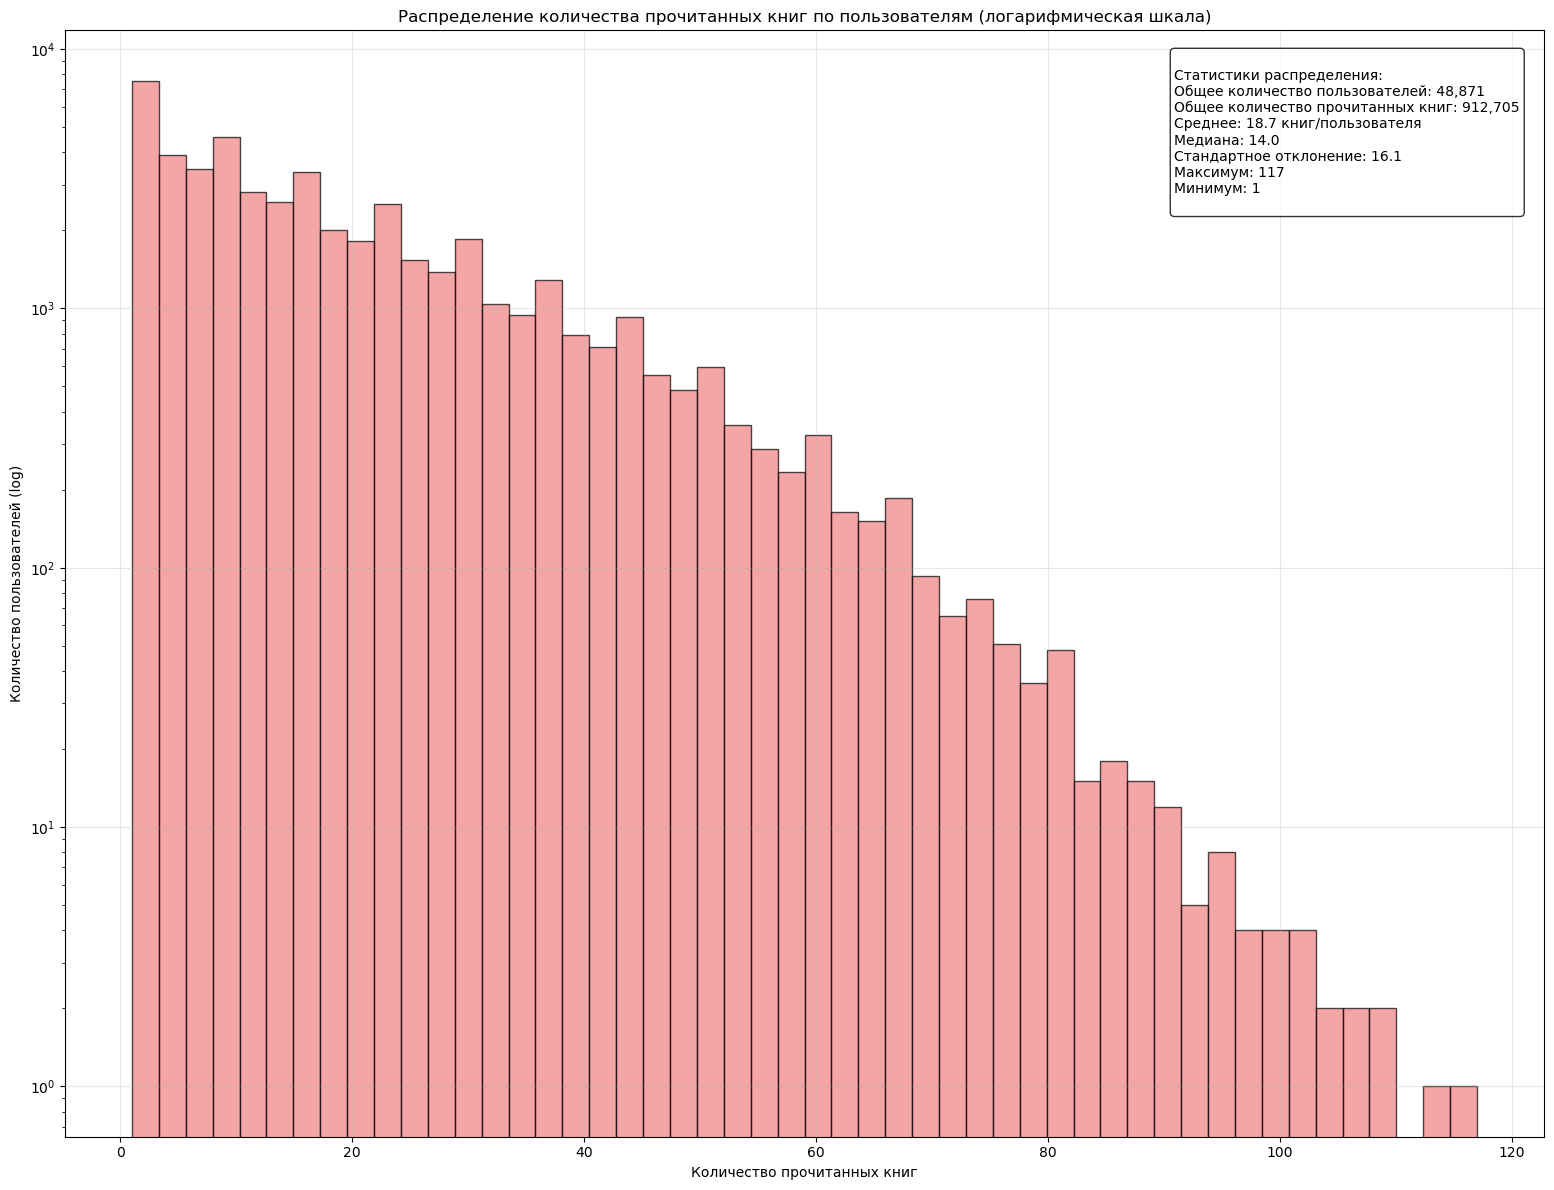

In [46]:
mu_books = user_activity_books['book_read_count'].mean()
sigma_books = user_activity_books['book_read_count'].std()

plt.figure(figsize=(16, 12))

plt.hist(
    user_activity_books['book_read_count'],
    bins=50,
    alpha=0.7, 
    color='lightcoral',
    edgecolor='black',
    log=True  # Логарифмическая шкала по Y
)

plt.title('Распределение количества прочитанных книг по пользователям (логарифмическая шкала)')
plt.xlabel('Количество прочитанных книг')
plt.ylabel('Количество пользователей (log)')
plt.grid(True, alpha=0.3)

stats_text = f'''
Статистики распределения:
Общее количество пользователей: {len(user_activity_books):,}
Общее количество прочитанных книг: {user_activity_books['book_read_count'].sum():,}
Среднее: {mu_books:.1f} книг/пользователя
Медиана: {user_activity_books['book_read_count'].median():.1f}
Стандартное отклонение: {sigma_books:.1f}
Максимум: {user_activity_books['book_read_count'].max():,}
Минимум: {user_activity_books['book_read_count'].min():,}
'''
plt.annotate(
    stats_text,
    xy=(0.75, 0.98),
    xycoords='axes fraction',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    verticalalignment='top',
    fontsize=10
)

plt.tight_layout()
plt.show()

<b>Проблема "холодного старта" здесь практически отсутствует. Но пользователи слишком похоже себя ведут.</b>

## Анализ популярности книг

In [49]:
book_popularity = ratings_df.groupby('book_id').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
book_popularity = book_popularity.sort_values('rating_count', ascending=False)

display(book_popularity['rating_count'].describe())
print(f"\nМедиана количества оценок: {book_popularity['rating_count'].median()}")

count    10000.000000
mean       597.647900
std       1267.289788
min          8.000000
25%        155.000000
50%        248.000000
75%        503.000000
max      22806.000000
Name: rating_count, dtype: float64


Медиана количества оценок: 248.0


In [50]:
total_books = len(book_popularity)
total_ratings = book_popularity['rating_count'].sum()

tail_threshold = book_popularity['rating_count'].quantile(0.25)
head_threshold = book_popularity['rating_count'].quantile(0.75)

popular_books = book_popularity[book_popularity['rating_count'] >= head_threshold]
not_popular_books = book_popularity[book_popularity['rating_count'] <= tail_threshold]
medium_books = book_popularity[(book_popularity['rating_count'] > tail_threshold) & (book_popularity['rating_count'] < head_threshold)]

popular_books_ratings = popular_books['rating_count'].sum()
not_popular_books_ratings = not_popular_books['rating_count'].sum()
medium_books_ratings = medium_books['rating_count'].sum()
assert (popular_books_ratings + not_popular_books_ratings + medium_books_ratings) == total_ratings

print(f"Популярные книги {len(popular_books)/total_books*100:.1f}% создают {popular_books_ratings:,} оценок из {total_ratings:,}")
print(f"Это {popular_books_ratings/total_ratings*100:.1f}% всех оценок")

print(f"Непопулярные книги {len(not_popular_books)/total_books*100:.1f}% создают {not_popular_books_ratings:,} оценок из {total_ratings:,}")
print(f"Это {not_popular_books_ratings/total_ratings*100:.1f}% всех оценок")

print(f"Средние книги {len(medium_books)/total_books*100:.1f}% создают {medium_books_ratings:,} оценок из {total_ratings:,}")
print(f"Это {medium_books_ratings/total_ratings*100:.1f}% всех оценок")

Популярные книги 25.1% создают 4,319,590 оценок из 5,976,479
Это 72.3% всех оценок
Непопулярные книги 25.1% создают 301,641 оценок из 5,976,479
Это 5.0% всех оценок
Средние книги 49.8% создают 1,355,248 оценок из 5,976,479
Это 22.7% всех оценок


<b>Популярные книги 25.1% создают 72.3% всех оценок - проблема "длинного хвоста".</b> Визуализируем его:

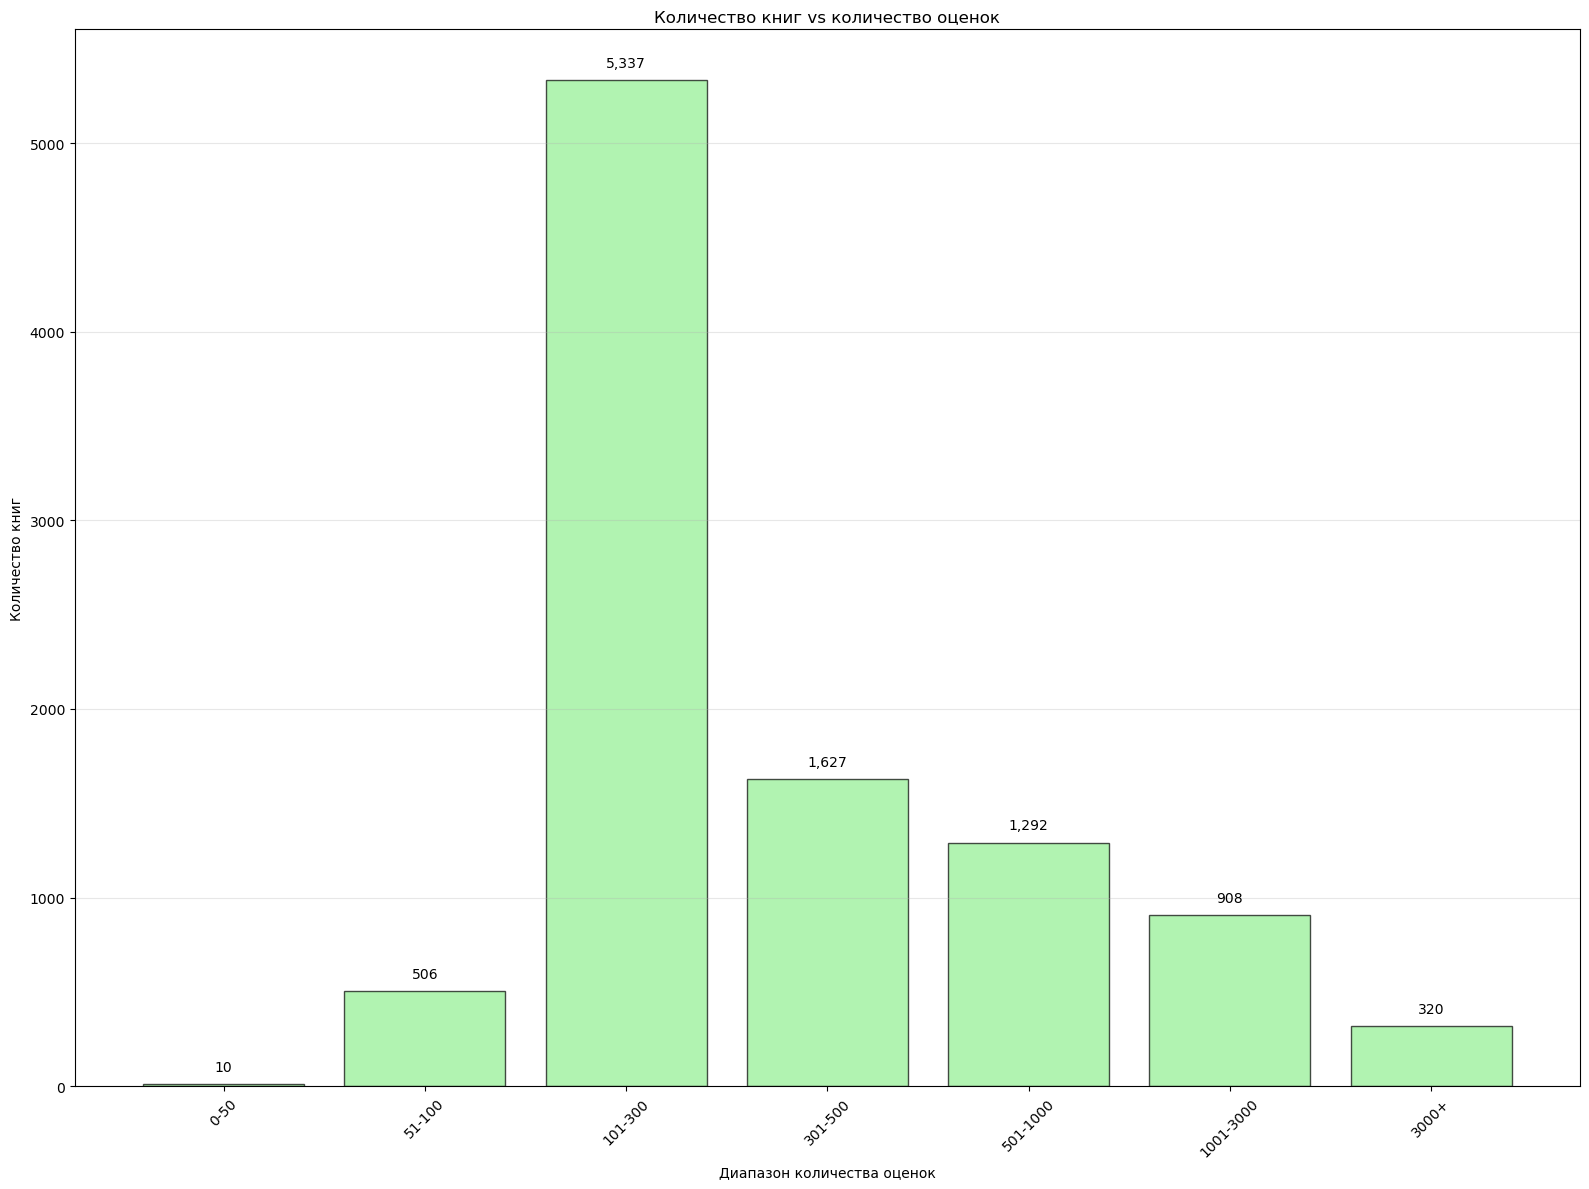

In [52]:
plt.figure(figsize=(16, 12))

bins = [0, 50, 100, 300, 500, 1000, 3000, float('inf')]
labels = ['0-50', '51-100', '101-300', '301-500', '501-1000', '1001-3000', '3000+']

book_popularity['rating_range'] = pd.cut(book_popularity['rating_count'], bins=bins, labels=labels)
rating_range_counts = book_popularity['rating_range'].value_counts().sort_index()

plt.bar(rating_range_counts.index, rating_range_counts.values, 
        alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Количество книг vs количество оценок')
plt.xlabel('Диапазон количества оценок')
plt.ylabel('Количество книг')
plt.grid(True, alpha=0.3, axis='y')

# Добавляем подписи значений
for i, count in enumerate(rating_range_counts.values):
    plt.text(i, count + max(rating_range_counts.values) * 0.01, 
             f'{count:,}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
def get_title(row):
    orig_title = str(row['original_title'])
    eng_title = str(row['title'])
    
    if any('\u0590' <= char <= '\u06FF' for char in orig_title):
        return eng_title + ' [араб.]'
    else:
        return orig_title

book_popularity_merged = book_popularity.merge(
    books_df[['book_id', 'title', 'original_title']],
    on='book_id',
    how='left'
)
book_popularity_merged = book_popularity_merged[book_popularity_merged['original_title'].notna() & book_popularity_merged['title'].notna()]
book_popularity_merged = book_popularity_merged.sort_values('rating_count', ascending=False)

top_10_books = book_popularity_merged.head(10)
print("\nТОП-10 САМЫХ ПОПУЛЯРНЫХ КНИГ:\n")
for i, (_, row) in enumerate(top_10_books.iterrows(), 1):
    print(f"{i:2d}. {get_title(row):60} | {row['rating_count']:5d} оценок | {row['avg_rating']:.2f} ★")


ТОП-10 САМЫХ ПОПУЛЯРНЫХ КНИГ:

 1. The Hunger Games                                             | 22806 оценок | 4.28 ★
 2. Harry Potter and the Philosopher's Stone                     | 21850 оценок | 4.35 ★
 3. To Kill a Mockingbird                                        | 19088 оценок | 4.33 ★
 4. Twilight                                                     | 16931 оценок | 3.21 ★
 5. The Great Gatsby                                             | 16604 оценок | 3.77 ★
 6. Catching Fire                                                | 16549 оценок | 4.13 ★
 7. Mockingjay                                                   | 15953 оценок | 3.85 ★
 8. Harry Potter and the Prisoner of Azkaban                     | 15855 оценок | 4.42 ★
 9. Harry Potter and the Chamber of Secrets                      | 15657 оценок | 4.23 ★
10. The Hobbit or There and Back Again                           | 15558 оценок | 4.15 ★


## Анализ тегов

In [55]:
tag_popularity = book_tags_df.groupby('tag_id').agg(
    tag_count=('count', 'count'),
).reset_index()
tag_popularity = tag_popularity.merge(
    tags_df[['tag_id', 'tag_name']],
    on='tag_id',
    how='left'
)
tag_popularity = tag_popularity.sort_values('tag_count', ascending=False)
display(tag_popularity['tag_count'].describe())
print(f"\nМедиана количества тегов: {tag_popularity['tag_count'].median()}")

count    34252.000000
mean        29.192806
std        277.254715
min          1.000000
25%          1.000000
50%          1.000000
75%          5.000000
max       9983.000000
Name: tag_count, dtype: float64


Медиана количества тегов: 1.0


In [56]:
total_tags = len(tag_popularity)
total_tags_count = tag_popularity['tag_count'].sum()

tail_threshold = 10
head_threshold = 90

popular_tags = tag_popularity[tag_popularity['tag_count'] >= head_threshold]
not_popular_tags = tag_popularity[tag_popularity['tag_count'] <= tail_threshold]
medium_tags = tag_popularity[(tag_popularity['tag_count'] > tail_threshold) & (tag_popularity['tag_count'] < head_threshold)]

popular_tags_count = popular_tags['tag_count'].sum()
not_popular_tags_count = not_popular_tags['tag_count'].sum()
medium_tags_count = medium_tags['tag_count'].sum()
assert (popular_tags_count + not_popular_tags_count + medium_tags_count) == total_tags_count

print(f"Популярные теги {len(popular_tags)/total_tags*100:.1f}% {popular_tags_count:,} из {total_tags_count:,}")
print(f"Это {popular_tags_count/total_tags_count*100:.1f}% всех тегов")

print(f"Непопулярные теги {len(not_popular_tags)/total_tags*100:.1f}% {not_popular_tags_count:,} из {total_tags_count:,}")
print(f"Это {not_popular_tags_count/total_tags_count*100:.1f}% всех тегов")

print(f"Средние теги {len(medium_tags)/total_tags*100:.1f}% {medium_tags_count:,} из {total_tags_count:,}")
print(f"Это {medium_tags_count/total_tags_count*100:.1f}% всех тегов")

Популярные теги 3.5% 822,676 из 999,912
Это 82.3% всех тегов
Непопулярные теги 84.9% 64,683 из 999,912
Это 6.5% всех тегов
Средние теги 11.5% 112,553 из 999,912
Это 11.3% всех тегов


Малое количество популярных тегов составляет 82% всех тегов, то есть зачастую выбираются одни и те же теги. Это сильно смещает рекомендации в сторону популярного контента и создает "эхо-камеру", где нишевые книги с уникальными тегами остаются незамеченными. 

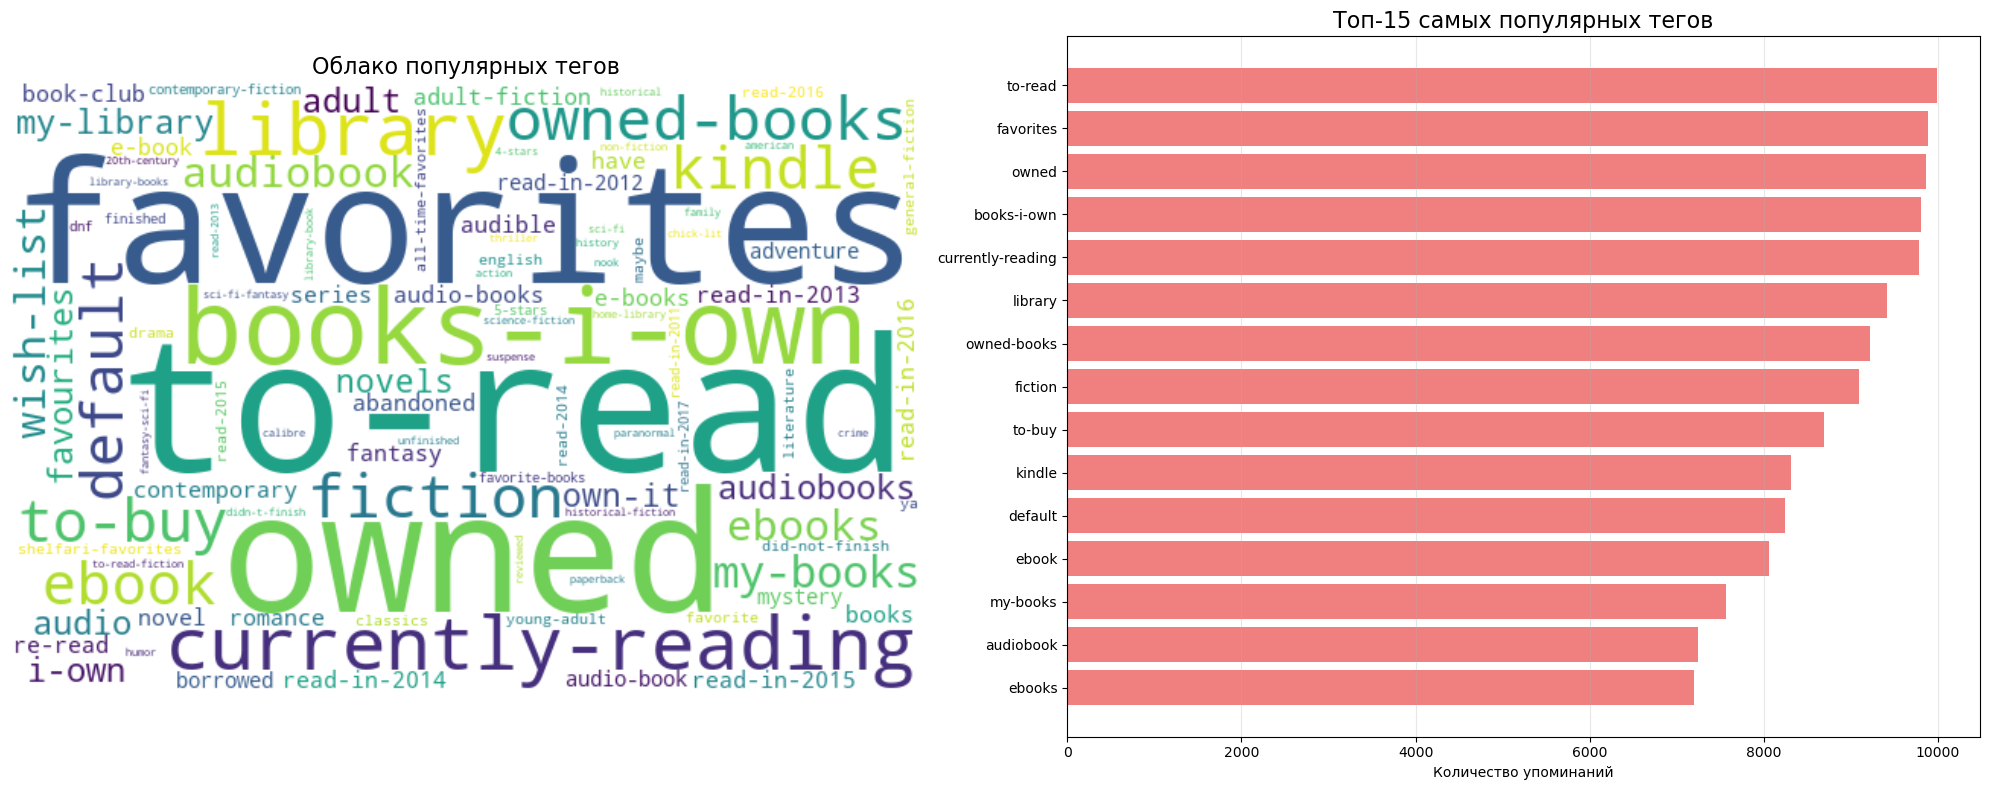

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

tag_freq_dict = dict(zip(tag_popularity['tag_name'], tag_popularity['tag_count']))
wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white', 
    max_words=100,
    colormap='viridis',
).generate_from_frequencies(tag_freq_dict)

ax1.imshow(wordcloud, interpolation='bilinear')
ax1.set_title('Облако популярных тегов', fontsize=16)
ax1.axis('off')

top_15 = tag_popularity.nlargest(15, 'tag_count')
bars = ax2.barh(range(len(top_15)), top_15['tag_count'], color='lightcoral')
ax2.set_yticks(range(len(top_15)))
ax2.set_yticklabels(top_15['tag_name'])
ax2.invert_yaxis()
ax2.set_xlabel('Количество упоминаний')
ax2.set_title('Топ-15 самых популярных тегов', fontsize=16)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы EDA

**Положительные аспекты:**
- Отличное покрытие: 53K пользователей, 48K активных читателей
- Высокая активность: в среднем 112 оценок и 19 книг на пользователя
- Нет проблемы холодного старта

**Потенциальные проблемы:**
1. Слишком однородное поведение пользователей
2. Низкая дисперсия может затруднить персонализацию
3. Возможная проблема "popularity bias" - система может рекомендовать только популярное

# Базовые и контентные модели

## Неперсонализированная модель Top-N

In [63]:
book_popularity = ratings_df.groupby('book_id').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
book_popularity_merged = book_popularity.merge(
    books_df[['book_id']],
    on='book_id',
    how='left'
)

min_ratings_threshold = 250
filtered_books = book_popularity_merged[book_popularity_merged['rating_count'] >= min_ratings_threshold]
top_books = filtered_books.sort_values('avg_rating', ascending=False)

print(f"Книг с ≥ {min_ratings_threshold} оценками: {len(filtered_books):,} ({len(filtered_books)/len(book_popularity_merged)*100:.1f}%)")
print(f"Отфильтровано книг: {len(book_popularity_merged) - len(filtered_books):,}")

Книг с ≥ 250 оценками: 4,959 (49.6%)
Отфильтровано книг: 5,041


In [64]:
top_books

,book_id,rating_count,avg_rating
3627,3628,482,4.829876
6360,6361,263,4.760456
4482,4483,384,4.747396
3274,3275,285,4.736842
1787,1788,652,4.728528
...,...,...,...
3145,3146,252,2.634921
4282,4283,304,2.628289
3549,3550,394,2.626904
1408,1409,283,2.512367


In [65]:
def base_recommend_top_popularity(user_id, top_books_id, ratings_df, k = 5):
    rated_books_id = ratings_df[ratings_df['user_id'] == user_id]['book_id'].tolist()
    used_books_id = list(set(rated_books_id))
    recommendations = []
    for i, book_id in enumerate(top_books_id):
       if book_id in used_books_id:
         continue
       recommendations.append({
           'book_id': book_id,
           'recommendation_order': i,
       })
       if len(recommendations) >= k:
         break
    return pd.DataFrame(recommendations)

In [66]:
top_books_id = top_books['book_id'].tolist()

recommendations = base_recommend_top_popularity(49925, top_books_id, ratings_df)

In [67]:
recommendations_books = recommendations.merge(
    books_df[['book_id', 'goodreads_book_id', 'title', 'image_url']],
    on='book_id',
    how='left'
).merge(
    top_books[['book_id', 'rating_count', 'avg_rating']],
    on='book_id',
    how='left'
).sort_values('recommendation_order')

recommendations_books[['book_id', 'title', 'avg_rating', 'rating_count', 'goodreads_book_id']]

,book_id,title,avg_rating,rating_count,goodreads_book_id
0,3628,The Complete Calvin and Hobbes,4.829876,482,24812
1,6361,There's Treasure Everywhere: A Calvin and Hobb...,4.760456,263,70489
2,4483,It's a Magical World: A Calvin and Hobbes Coll...,4.747396,384,24814
3,3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...",4.736842,285,8
4,1788,The Calvin and Hobbes Tenth Anniversary Book,4.728528,652,24813


Вычислительная сложность: 
* обучение O(R)
* предсказание O(N)

где R - размер матрицы рейтингов, N - количество рекомендаций

## Контентная модель

In [70]:
def create_book_profiles(books_df, book_tags_df, tags_df):
    books_with_tags = books_df[['book_id', 'goodreads_book_id', 'title', 'original_title']].merge(
        book_tags_df[['goodreads_book_id', 'tag_id', 'count']],
        on='goodreads_book_id',
        how='left'
    ).merge(
        tags_df[['tag_id', 'tag_name']],
        on='tag_id',
        how='left'
    )
    
    profiles = {}
    for _, row in books_with_tags.iterrows():
        book_id = row['book_id']
        # это итерация не просто по книгам, а по тегам, поэтому книга уже могла быть добавлена
        if book_id not in profiles:
            title = row['title']
            profiles[book_id] = {
                'title': title,
                'weighted_tags': [],
                'all_tags': set()
            }

        tag_name = str(row['tag_name']).lower().replace(' ', '_')
        count = max(int(row['count']), 1)
        # с помощью логарифмирования сокращаем объем профилей с миллионов до десятков тысяч
        log_weight = int(np.log2(count))
        profiles[book_id]['weighted_tags'].extend([tag_name] * log_weight)
        profiles[book_id]['all_tags'].add(row['tag_name'])

    book_profiles = []
    for book_id, data in profiles.items():        
        book_profiles.append({
            'book_id': book_id,
            'title': data['title'],
            # будем использовать эту длинную строку для tfidf
            'profile': f"{data['title']} {' '.join(data['weighted_tags'])}".strip(),
            'tags_count': len(data['all_tags']),
            'all_tags': ' '.join(data['all_tags'])
        })
    
    return pd.DataFrame(book_profiles)

In [71]:
book_profiles_df = create_book_profiles(books_df, book_tags_df, tags_df)

for i, (_, row) in enumerate(book_profiles_df.head(3).iterrows(), 1):
    print(f"{i}. Book ID: {row['book_id']}")
    print(f"   Название: {row['title']}")
    print(f"   Теги: {row['all_tags'][:100]}...")
    print(f"   Профиль: {row['profile'][:100]}...")
    print(f"   Длина профиля: {len(row['profile']):,} символов")

1. Book ID: 1
   Название: The Hunger Games (The Hunger Games, #1)
   Теги: coming-of-age read-2012 reread contemporary books-i-own owned future science-fiction speculative-fic...
   Профиль: The Hunger Games (The Hunger Games, #1) favorites favorites favorites favorites favorites favorites ...
   Длина профиля: 9,974 символов
2. Book ID: 2
   Название: Harry Potter and the Sorcerer's Stone (Harry Potter, #1)
   Теги: childrens-books reread contemporary books-i-own owned kids-books favourite-books series favorite wit...
   Профиль: Harry Potter and the Sorcerer's Stone (Harry Potter, #1) to-read to-read to-read to-read to-read to-...
   Длина профиля: 10,500 символов
3. Book ID: 3
   Название: Twilight (Twilight, #1)
   Теги: reread contemporary movies books-i-own stephanie-meyer books-i-have read-in-2009 guilty-pleasure sci...
   Профиль: Twilight (Twilight, #1) young-adult young-adult young-adult young-adult young-adult young-adult youn...
   Длина профиля: 9,238 символов


In [72]:
def create_tfidf_matrix(book_profiles_df, max_features=15000, min_df=0.01, max_df=0.75):
    tfidf_vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        stop_words='english',
        ngram_range=(1, 3)
    )
    tfidf_matrix = tfidf_vectorizer.fit_transform(book_profiles_df['profile'])
    
    return tfidf_matrix, tfidf_vectorizer

In [73]:
tfidf_matrix, tfidf_vectorizer = create_tfidf_matrix(book_profiles_df)

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nПримеры features: {feature_names[:20]}")


Примеры features: ['100' '100 best' '100 books' '1000' '1000 guardian' '1000 guardian 1000'
 '1001' '1001 1001' '1001 1001 1001' '1001 books' '1001 books 1001'
 '1001 books read' '1001 import' '1001 import 1001' '1001 read'
 '1001 read 1001' '1800s' '1800s 1800s' '1800s 1800s 1800s' '1900s']


In [74]:
def get_similar_books(book_id, book_profiles_df, tfidf_matrix, N=5):
    book_index = book_profiles_df[book_profiles_df['book_id'] == book_id].index[0]
    target_vector = tfidf_matrix[book_index:book_index + 1]
    cosine_similarities = cosine_similarity(
        target_vector, 
        tfidf_matrix
    ).flatten()
    similar_indexes_asc = cosine_similarities.argsort()
    similar_indexes_desc = similar_indexes_asc[::-1]
    # [1:] чтобы исключить book_id книгу(нулевой индекс сама книга book_id)
    similar_indexes = similar_indexes_desc[1:N+1] 

    similar_books = []
    for id in similar_indexes:
        similarity_score = cosine_similarities[id]
        similar_book_id = book_profiles_df.iloc[id]['book_id']        
        similar_books.append({
            'book_id': similar_book_id,
            'similarity_score': similarity_score,
        })

    return pd.DataFrame(similar_books)

In [75]:
book_popularity = ratings_df.groupby('book_id').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
book_popularity_merged = book_popularity.merge(
    books_df[['book_id', 'title']],
    on='book_id',
    how='left'
)
target_book_id = 3628
target_book = book_popularity_merged[book_popularity_merged['book_id'] == target_book_id]
target_book[['book_id', 'title', 'avg_rating', 'rating_count']]

,book_id,title,avg_rating,rating_count
3627,3628,The Complete Calvin and Hobbes,4.829876,482


In [76]:
book_profiles_df = create_book_profiles(books_df, book_tags_df, tags_df)
tfidf_matrix, tfidf_vectorizer = create_tfidf_matrix(book_profiles_df)
similar_books_df = get_similar_books(target_book_id, book_profiles_df, tfidf_matrix)

In [77]:
similar_books_df

,book_id,similarity_score
0,6590,0.955879
1,5580,0.954152
2,780,0.953193
3,6361,0.952597
4,6920,0.952024


In [78]:
recommendations_books = similar_books_df.merge(
    books_df[['book_id', 'title', 'image_url']],
    on='book_id',
    how='left'
).merge(
    book_popularity_merged[['book_id', 'rating_count', 'avg_rating']],
    on='book_id',
    how='left'
).sort_values('similarity_score', ascending=False)

recommendations_books[['book_id', 'title', 'similarity_score', 'avg_rating', 'rating_count']]

,book_id,title,similarity_score,avg_rating,rating_count
0,6590,The Authoritative Calvin and Hobbes: A Calvin ...,0.955879,4.757202,243
1,5580,The Calvin and Hobbes Lazy Sunday Book,0.954152,4.689139,267
2,780,Calvin and Hobbes,0.953193,4.661406,1394
3,6361,There's Treasure Everywhere: A Calvin and Hobb...,0.952597,4.760456,263
4,6920,The Indispensable Calvin and Hobbes,0.952024,4.766355,214


Вычислительная сложность: 
* обучение O(I·T)
* предсказание O(I·T·N)

где I - число книг, T - число уникальных тегов, N - количество рекомендаций

для оптимизации на большом объеме данных можно использовать разряженные структуры данных

# Коллаборативная фильтрация

In [81]:
def create_user_item_matrix(ratings_df):
    user_item_matrix = ratings_df.pivot_table(
        index='user_id',
        columns='book_id', 
        values='rating',
        fill_value=0
    )
    
    return user_item_matrix

In [82]:
user_item_matrix = create_user_item_matrix(ratings_df)

print("Матрица взаимодействий пользователь — книга:")
print(f"Размер: {user_item_matrix.shape}")

Матрица взаимодействий пользователь — книга:
Размер: (53424, 10000)


In [83]:
def calculate_item_similarities(user_item_matrix):
    all_books = user_item_matrix.columns
    data = user_item_matrix.values.T
    # средняя оценка по всем книгам для каждого пользователя
    user_means = data.mean(axis=1, keepdims=True)
    # нормализуем оценки каждого пользователя(кто-то систематически завышает, кто-то занижает)
    normalized_data = data - user_means
    
    similarity_matrix = cosine_similarity(normalized_data)
        
    return similarity_matrix

In [84]:
similarity_matrix = calculate_item_similarities(user_item_matrix)

print("Матрица попарных схожестей:")
print(f"Размер: {similarity_matrix.shape} (книги × книги)")

Матрица попарных схожестей:
Размер: (10000, 10000) (книги × книги)


In [85]:
def predict_rating_item_based(user_id, book_id, user_item_matrix, similarity_matrix, k=5):
    user_ratings = user_item_matrix.loc[user_id].values

    book_index = user_item_matrix.columns.get_loc(book_id)
    book_similarities = similarity_matrix[book_index]
    
    valid_indices = []
    valid_similarities = []
    for other_book_index, similarity in enumerate(book_similarities):
        rating = user_ratings[other_book_index]
        if similarity > 0 and rating > 0 and other_book_index != book_index:
            valid_indices.append(other_book_index)
            valid_similarities.append(similarity)
    if len(valid_similarities) == 0:
        return 0

    similarity_sum = 0
    weighted_sum = 0
    # лучшие схожести по книге book_id для user_id
    top_k_indices = np.argsort(valid_similarities)[::-1][:k]
    for i in top_k_indices:
        other_book_index = valid_indices[i]
        similarity = valid_similarities[i]

        rating = user_ratings[other_book_index]
        similarity_sum += similarity
        weighted_sum += similarity * rating
    if similarity_sum == 0:
        return 0
    
    predicted_rating = weighted_sum / similarity_sum
    return predicted_rating

In [86]:
def get_item_based_recommendations(user_id, user_item_matrix, similarity_matrix, k=5):
    user_index = user_item_matrix.index.get_loc(user_id)
    user_ratings = user_item_matrix.iloc[user_index]
    unrated_books = user_ratings[user_ratings == 0].index

    # рекомендации по всем книгам, которые пользователь не оценивал(не видел)
    predictions = []
    for book_id in unrated_books:
        predicted_rating = predict_rating_item_based(
            user_id, book_id, user_item_matrix, similarity_matrix, k
        )
        if predicted_rating > 0:
            predictions.append({
                'book_id': book_id,
                'predicted_rating': predicted_rating,
            })
    predictions.sort(key=lambda x: x['predicted_rating'], reverse=True)
    return pd.DataFrame(predictions[:k])

In [87]:
user_item_matrix = create_user_item_matrix(ratings_df)
similarity_matrix = calculate_item_similarities(user_item_matrix)

target_user_id = 2
get_item_based_recommendations(target_user_id, user_item_matrix, similarity_matrix, 20)

,book_id,predicted_rating
0,4372,5.0
1,376,5.0
2,389,5.0
3,783,5.0
4,1399,5.0
5,1523,5.0
6,2480,5.0
7,2532,5.0
8,2711,5.0
9,2756,5.0


Вычислительная сложность: 
* обучение O(U²·I)
* предсказание O(I²·N)

где I - число книг, U - число пользователей, N - количество рекомендаций

для оптимизации на большом объеме данных можно использовать разряженные структуры данных

Вычислительная сложность подхода:

1. **Расчет матрицы схожестей**: O(n² × m), где n - количество книг, m - количество пользователей
   - Попарное сравнение всех книг между собой
   - При 10,000 книг: ~100 млн операций

2. **Предсказание оценок**: O(n × k) на пользователя
   - Для каждого непросмотренного фильма проверяем k похожих
   - При 1,000 непросмотренных книг: 1,000 × k операций

3. **Память**: O(n²) для хранения матрицы схожестей
   - При 10,000 книг: 100 млн элементов (800 МБ)

Оптимизации:

### 1. **Семплирование и аппроксимация**
- Работать только с популярными книгами (top-N по количеству оценок)

### 2. **Разреженные представления**
- Хранить только значимые схожести (выше порога)
- Использовать разреженные матрицы и структуры данных§

### 3. **Индексирование и кэширование**
- Предварительно вычислять топ-K похожих для каждой книги
- Кэшировать результаты предсказаний

# Matrix Factorization

In [91]:
def prepare_surprise_data(ratings_df):
    surprise_data = ratings_df[['user_id', 'book_id', 'rating']].copy()
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(surprise_data, reader)

    return data

In [92]:
data = prepare_surprise_data(ratings_df)

In [93]:
loo = LeaveOneOut(n_splits=1, random_state=42)
trainset, testset = [], []
for train, test in loo.split(data):
    trainset = train
    testset = test

print(f"Обучающая выборка: {trainset.n_ratings:,} оценок")
print(f"Тестовая выборка: {len(testset):,} оценок")

Обучающая выборка: 5,923,055 оценок
Тестовая выборка: 53,424 оценок


In [94]:
test_users = set()
test_items = set()
for uid, iid, rating in testset:
    test_users.add(uid)
    test_items.add(iid)

print(f"Уникальных пользователей в тесте: {len(test_users):,}")
print(f"Уникальных книг в тесте: {len(test_items):,}")

# Проверяем, что у каждого пользователя ровно одна оценка в тесте
user_test_counts = {}
for uid, iid, rating in testset:
    user_test_counts[uid] = user_test_counts.get(uid, 0) + 1

multiple_ratings_users = [uid for uid, count in user_test_counts.items() if count > 1]
if multiple_ratings_users:
    print(f"⚠️  Предупреждение: {len(multiple_ratings_users)} пользователей имеют >1 оценки в тесте")
else:
    print("✅ Каждый пользователь имеет ровно одну оценку в тесте")

Уникальных пользователей в тесте: 53,424
Уникальных книг в тесте: 8,707
✅ Каждый пользователь имеет ровно одну оценку в тесте


In [95]:
def train_svd_model(trainset, random_state=42):
    model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=random_state)
    model.fit(trainset)
    
    return model

In [96]:
svd_model = train_svd_model(trainset)

test_predictions = svd_model.test(testset)

rmse = accuracy.rmse(test_predictions, verbose=False)
mae = accuracy.mae(test_predictions, verbose=False)

print(f"RMSE на тесте: {rmse:.4f}")
print(f"MAE на тесте: {mae:.4f}")

RMSE на тесте: 0.8165
MAE на тесте: 0.6278


In [97]:
def get_recommendations_svd(user_id, model, books_df, ratings_df, k=5):    
    user_rated_books = set(ratings_df[ratings_df['user_id'] == user_id]['book_id'])
    all_books = set(ratings_df['book_id'])
    books_to_recommend = all_books - user_rated_books

    predictions = []
    for book_id in list(books_to_recommend):
        predicted_rating = model.predict(user_id, book_id).est
        predictions.append({
            'book_id': book_id,
            'predicted_rating': predicted_rating
        })
    
    recommendations = sorted(predictions, key=lambda x: x['predicted_rating'], reverse=True)[:k]
    return pd.DataFrame(recommendations)

In [98]:
data = prepare_surprise_data(ratings_df)
loo = LeaveOneOut(n_splits=1, random_state=42)
trainset, testset = [], []
for train, test in loo.split(data):
    trainset = train
    testset = test
svd_model = train_svd_model(trainset)

target_user_id = 123
recommendations_df = get_recommendations_svd(target_user_id, svd_model, books_df, ratings_df, k=5)

recommendations_merged = recommendations_df.merge(
    books_df[['book_id', 'title']],
    on='book_id',
    how='left'
).sort_values('predicted_rating', ascending=False)
recommendations_merged

,book_id,predicted_rating,title
0,2844,5.000000,Left to Tell: Discovering God Amidst the Rwand...
1,267,4.986602,The Nightingale
2,864,4.967746,"The Fiery Cross (Outlander, #5)"
3,53,4.965845,"Eragon (The Inheritance Cycle, #1)"
4,4868,4.963564,Jesus the Christ


# Оценка и сравнение моделей

Разделяем выборку по рейтингам на тренировочную и тестовую, так чтобы 80% оценок каждого юзера попали в тренировочный датасет, а оставшиеся 20% в тестовый.

In [155]:
train_ratings = []
test_ratings = []
test_size = 0.1

for user_id in ratings_df['user_id'].unique():
    user_ratings = ratings_df[ratings_df['user_id'] == user_id]
    # сортируем по индексу (предполагая хронологический порядок)
    user_ratings = user_ratings.sort_index()
    
    if len(user_ratings) >= 5:
        split_idx = int(len(user_ratings) * (1 - test_size))
        train_user = user_ratings.iloc[:split_idx]
        test_user = user_ratings.iloc[split_idx:]
        
        train_ratings.append(train_user)
        test_ratings.append(test_user)
    else:
        # Для пользователей с малым количеством оценок - все в train
        train_ratings.append(user_ratings)

train_ratings_df = pd.concat(train_ratings)
test_ratings_df = pd.concat(test_ratings)

print(f"Train ratings: {len(train_ratings_df):,}")
print(f"Test ratings: {len(test_ratings_df):,}")
print(f"Unique users in train: {train_ratings_df['user_id'].nunique()}")
print(f"Unique users in test: {test_ratings_df['user_id'].nunique()}")

Train ratings: 5,354,846
Test ratings: 621,633
Unique users in train: 53424
Unique users in test: 53424


Будем оценивать рекомендации для каждого юзера для нескольких k. Чтобы посчитать метрики по методу возьмем N пользователей и усредним значения.

In [156]:
def calculate_relevance_metrics(method, user_id, recommendations_book_ids, ratings, relevance_threshold=4):
    relevant_items = set(ratings[(ratings['user_id'] == user_id) & (ratings['rating'] >= relevance_threshold)]['book_id'].tolist())
    all_test_items = set(ratings[ratings['user_id'] == user_id]['book_id'].tolist())
    
    metrics = {
        'method': method,
    }
    
    for k in [3, 5, 10, 20, 30]:
        rec_k = recommendations_book_ids[:k]
        if len(rec_k) <= 0 or len(relevant_items) <= 0:
            metrics.update({
                f'precision@{k}': 0,
                f'recall@{k}': 0,
                f'ndcg@{k}': 0
            })
            continue

        relevant_in_rec = len(set(rec_k) & relevant_items)
        precision = relevant_in_rec / len(rec_k)
        
        recall = relevant_in_rec / len(relevant_items)

        dcg = 0
        for i, item in enumerate(rec_k):
            if item in relevant_items:
                dcg += 1 / np.log2(i + 2)
        ideal_relevance = min(len(relevant_items), k)
        idcg = sum(1 / np.log2(i + 2) for i in range(ideal_relevance))
        ndcg = dcg / idcg
        
        metrics.update({
            f'precision@{k}': precision,
            f'recall@{k}': recall,
            f'ndcg@{k}': ndcg
        })
    
    metrics.update({
        'relevant_items_count': len(relevant_items),
        'items_count': len(all_test_items)
    })
    
    return metrics

In [159]:
test_users_sample = list(test_users)[:100]

all_metrics_popularity = []
for i, user_id in enumerate(test_users_sample):
    if i % 10 == 0:
        print(f"TP Обработано {i} пользователей...")
    recommendations_popularity = base_recommend_top_popularity(user_id, top_books_id, train_ratings_df, k=30)
    recommendations_popularity_book_ids = recommendations_popularity.sort_values('recommendation_order')['book_id'].tolist()
    metrics = calculate_relevance_metrics('popularity', user_id, recommendations_popularity_book_ids, test_ratings_df)
    all_metrics_popularity.append(metrics)

TP Обработано 0 пользователей...
TP Обработано 10 пользователей...
TP Обработано 20 пользователей...
TP Обработано 30 пользователей...
TP Обработано 40 пользователей...
TP Обработано 50 пользователей...
TP Обработано 60 пользователей...
TP Обработано 70 пользователей...
TP Обработано 80 пользователей...
TP Обработано 90 пользователей...


In [166]:
user_item_matrix_train = create_user_item_matrix(train_ratings_df)
similarity_matrix_train = calculate_item_similarities(user_item_matrix_train)
all_metrics_cf = []
for i, user_id in enumerate(test_users_sample):
    if i % 10 == 0:
        print(f"CF Обработано {i} пользователей...")
    recommendations_cf = get_item_based_recommendations(user_id, user_item_matrix_train, similarity_matrix_train, 30)
    recommendations_cf_book_ids = recommendations_cf.sort_values('predicted_rating', ascending=False)['book_id'].tolist()
    metrics = calculate_relevance_metrics('item_cf', user_id, recommendations_cf_book_ids, test_ratings_df)
    all_metrics_cf.append(metrics)

CF Обработано 0 пользователей...
CF Обработано 10 пользователей...
CF Обработано 20 пользователей...
CF Обработано 30 пользователей...
CF Обработано 40 пользователей...
CF Обработано 50 пользователей...
CF Обработано 60 пользователей...
CF Обработано 70 пользователей...
CF Обработано 80 пользователей...
CF Обработано 90 пользователей...


In [165]:
reader = Reader(rating_scale=(1, 5))
train_data = Dataset.load_from_df(train_ratings_df[['user_id', 'book_id', 'rating']].copy(), reader)
trainset = train_data.build_full_trainset()
testset = list(zip(
    test_ratings_df['user_id'],
    test_ratings_df['book_id'],
    test_ratings_df['rating']
))
all_metrics_svd = []
for i, user_id in enumerate(test_users_sample):
    if i % 10 == 0:
        print(f"SVD Обработано {i} пользователей...")
    recommendations_svd = get_recommendations_svd(user_id, svd_model, books_df, train_ratings_df, k=30)
    recommendations_svd_book_ids = recommendations_svd.sort_values('predicted_rating', ascending=False)['book_id'].tolist()
    metrics = calculate_relevance_metrics('svd', user_id, recommendations_svd_book_ids, test_ratings_df)
    all_metrics_svd.append(metrics)

SVD Обработано 0 пользователей...
SVD Обработано 10 пользователей...
SVD Обработано 20 пользователей...
SVD Обработано 30 пользователей...
SVD Обработано 40 пользователей...
SVD Обработано 50 пользователей...
SVD Обработано 60 пользователей...
SVD Обработано 70 пользователей...
SVD Обработано 80 пользователей...
SVD Обработано 90 пользователей...


In [173]:
def aggregate_metrics(all_metrics, method_name):
    metrics_df = pd.DataFrame(all_metrics)
    
    average_metrics = {
        'method': method_name,
        'users_count': len(metrics_df)
    }
    
    for k in [3, 5, 10, 20, 30]:
        average_metrics[f'precision@{k}'] = metrics_df[f'precision@{k}'].mean()
        average_metrics[f'recall@{k}'] = metrics_df[f'recall@{k}'].mean()
        average_metrics[f'ndcg@{k}'] = metrics_df[f'ndcg@{k}'].mean()
    average_metrics['avg_relevant_items'] = metrics_df['relevant_items_count'].mean()
    average_metrics['avg_test_items'] = metrics_df['items_count'].mean()
    
    return pd.DataFrame([average_metrics])

results = []
if all_metrics_popularity:
    result_popularity = aggregate_metrics(all_metrics_popularity, 'popularity')
    results.append(result_popularity)
if all_metrics_cf:
    result_cf = aggregate_metrics(all_metrics_cf, 'item_cf')
    results.append(result_cf)
if all_metrics_svd:
    result_svd = aggregate_metrics(all_metrics_svd, 'svd')
    results.append(result_svd)
final_results = pd.concat(results, ignore_index=True)

In [168]:
for _, row in final_results.iterrows():
    print(f"\n--- {row['method'].upper()} ---")
    print(f"Пользователей: {row['users_count']}")
    print(f"Среднее релевантных items: {row['avg_relevant_items']:.2f}")
    
    for k in [3, 5, 10, 20, 30]:
        print(f"K={k}: Precision={row[f'precision@{k}']:.4f}, Recall={row[f'recall@{k}']:.4f}, nDCG={row[f'ndcg@{k}']:.4f}")

final_results.round(6)


--- POPULARITY ---
Пользователей: 100
Среднее релевантных items: 6.80
K=3: Precision=0.0000, Recall=0.0000, nDCG=0.0000
K=5: Precision=0.0000, Recall=0.0000, nDCG=0.0000
K=10: Precision=0.0000, Recall=0.0000, nDCG=0.0000
K=20: Precision=0.0010, Recall=0.0020, nDCG=0.0010
K=30: Precision=0.0007, Recall=0.0020, nDCG=0.0010

--- ITEM_CF ---
Пользователей: 100
Среднее релевантных items: 6.80
K=3: Precision=0.0000, Recall=0.0000, nDCG=0.0000
K=5: Precision=0.0000, Recall=0.0000, nDCG=0.0000
K=10: Precision=0.0000, Recall=0.0000, nDCG=0.0000
K=20: Precision=0.0000, Recall=0.0000, nDCG=0.0000
K=30: Precision=0.0000, Recall=0.0000, nDCG=0.0000

--- SVD ---
Пользователей: 100
Среднее релевантных items: 6.80
K=3: Precision=0.0100, Recall=0.0035, nDCG=0.0106
K=5: Precision=0.0100, Recall=0.0060, nDCG=0.0103
K=10: Precision=0.0070, Recall=0.0077, nDCG=0.0089
K=20: Precision=0.0060, Recall=0.0130, nDCG=0.0116
K=30: Precision=0.0057, Recall=0.0207, nDCG=0.0145


,method,users_count,precision@3,recall@3,ndcg@3,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10,precision@20,recall@20,ndcg@20,precision@30,recall@30,ndcg@30,avg_relevant_items,avg_test_items
0,popularity,100,0.00,0.00000,0.000000,0.00,0.00000,0.000000,0.000,0.000000,0.000000,0.001,0.002020,0.001024,0.000667,0.002020,0.001024,6.8,10.64
1,item_cf,100,0.00,0.00000,0.000000,0.00,0.00000,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,6.8,10.64
2,svd,100,0.01,0.00354,0.010614,0.01,0.00604,0.010295,0.007,0.007706,0.008948,0.006,0.012996,0.011551,0.005667,0.020738,0.014527,6.8,10.64


# Гибридизация и выводы

## Предлагаемая стратегия гибридизации:

**1. Для новых пользователей (холодный старт):**
- **Контентные рекомендации** + **Популярные книги**
новые пользователи не имеют истории оценок, поэтому используем популярные книги для начальных рекомендаций

**2. Для пользователей с умеренной активностью (50-120 оценок):**
- **Item-Based CF** + **Контентная фильтрация** + **Популярность**
достаточно данных для персонализации, но недостаточно для сложных моделей

**3. Для активных пользователей (более 120 оценок):**
- **SVD** + **Item-Based CF** + **Контентные рекомендации для диверсификации**
максимальная персонализация с элементами диверсификации для предотвращения пузыря фильтров

## Выводы по работе

Наилучшая модель и обоснование

**SVD (Matrix Factorization) показала наилучшее качество** по всем метрикам (Precision@K, Recall@K, nDCG@K). Это объясняется следующими факторами:

- **Способность выявлять скрытые паттерны**: SVD обнаруживает латентные факторы, которые не очевидны в исходных данных
- **Эффективная работа с разреженностью**: алгоритм хорошо справляется с разреженными матрицами пользователь-книга
- **Масштабируемость**: после обучения быстрая генерация рекомендаций
- **Учет косвенных связей**: находит сходства между пользователями и книгами, которые не пересекаются напрямую

## Сильные и слабые стороны моделей

Popularity-Based модель:

**Сильные стороны:**
- Простота реализации и интерпретации
- Стабильная работа для новых пользователей
- Высокая покрываемость каталога
- Низкие вычислительные затраты

**Слабые стороны:**
- Отсутствие персонализации
- Эффекта Матфея
- Неспособность рекомендовать нишевый контент

Контентная модель:

**Сильные стороны:**
- Решает проблему холодного старта для новых книг
- Высокая интерпретируемость рекомендаций
- Независимость от данных других пользователей
- Хорошо работает с нишевым контентом

**Слабые стороны:**
- Низкая точность для сложных пользовательских предпочтений
- Не учитывает вкусы похожих пользователей

Item-Based Collaborative Filtering:

**Сильные стороны:**
- Хорошая интерпретируемость ("похоже на то, что вам нравится")
- Быстрое обновление при новых оценках
- Устойчивость к изменениям предпочтений
- Естественная диверсификация

**Слабые стороны:**
- Высокая вычислительная сложность для больших каталогов
- Проблема холодного старта для новых книг
- Зависимость от точности вычисления схожести

SVD (Matrix Factorization):

**Сильные стороны:**
- Эффективная работа с разреженными данными
- Обнаружение сложных неочевидных паттернов
- Хорошая масштабируемость после обучения

**Слабые стороны:**
- Сложность интерпретации рекомендаций
- Медленное переобучение на новых данных
- Чувствительность к гиперпараметрам
- Требовательность к вычислительным ресурсам при обучении

## Перспективы улучшения системы

1. Продвинутые эмбеддинги для текста
- **BERT для описаний книг**: использование контекстных эмбеддингов для лучшего понимания семантики
- **Word2Vec/FastText для жанров и тегов**: создание семантических представлений жанров
- **Sentence transformers** для векторного поиска по аннотациям

 2. Обогащение пользовательских фич
- Демографические данные (возраст, пол, локация)
- Поведенческие паттерны (время чтения, частота, предпочтения по жанрам)
- Социальные связи и влияние (если доступны данные о друзьях)

3. Контекстные рекомендации
- Учет времени года, дня недели, погоды
- Устройство чтения (мобильное, десктоп, ридер)
- Местоположение пользователя

## Заключение

Разработанный прототип демонстрирует, что даже базовые реализации рекомендательных систем могут обеспечить значительную ценность для пользователей. Гибридный подход, объединяющий сильные стороны различных методов, является наиболее перспективным направлением для построения production-системы. Ключевой вывод: не существует "серебряной пули" — оптимальная стратегия зависит от конкретного контекста, данных и бизнес-требований.